In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from datetime import datetime
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)

print("Libraries loaded!")

Libraries loaded!


In [2]:
PATH = 'E:/portfoilo/olist-ecommerce-analysis/data/raw/'

orders    = pd.read_csv(PATH + 'olist_orders_dataset.csv')
customers = pd.read_csv(PATH + 'olist_customers_dataset.csv')
items     = pd.read_csv(PATH + 'olist_order_items_dataset.csv')

# แปลงวันที่
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

# กรองเฉพาะ delivered orders
orders_delivered = orders[orders['order_status'] == 'delivered'].copy()

print(f"Orders: {orders_delivered.shape[0]:,}")
print(f"Customers: {customers.shape[0]:,}")
print(f"Items: {items.shape[0]:,}")

Orders: 96,478
Customers: 99,441
Items: 112,650


In [3]:
# กำหนดวันอ้างอิง = วันที่ล่าสุดในข้อมูล + 1 วัน
# (เพื่อให้ลูกค้าที่ซื้อวันสุดท้ายมี recency = 1 ไม่ใช่ 0)
reference_date = orders_delivered['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
print(f"Reference date: {reference_date.date()}")

# รวม orders กับ customers และ items
df = orders_delivered.merge(customers, on='customer_id')
df = df.merge(items[['order_id','price']], on='order_id')

# คำนวณ RFM ต่อลูกค้า 1 คน
rfm = df.groupby('customer_unique_id').agg(
    recency   = ('order_purchase_timestamp',
                 lambda x: (reference_date - x.max()).days),
    frequency = ('order_id', 'nunique'),
    monetary  = ('price', 'sum')
).reset_index()

rfm['monetary'] = rfm['monetary'].round(2)

print(rfm.describe())
print(f"\nตัวอย่าง RFM:")
print(rfm.head())

Reference date: 2018-08-30
            recency     frequency      monetary
count  93358.000000  93358.000000  93358.000000
mean     237.941773      1.033420    141.621480
std      152.591453      0.209097    215.694014
min        1.000000      1.000000      0.850000
25%      114.000000      1.000000     47.650000
50%      219.000000      1.000000     89.730000
75%      346.000000      1.000000    154.737500
max      714.000000     15.000000  13440.000000

ตัวอย่าง RFM:
                 customer_unique_id  recency  frequency  monetary
0  0000366f3b9a7992bf8c76cfdf3221e2      112          1    129.90
1  0000b849f77a49e4a4ce2b2a4ca5be3f      115          1     18.90
2  0000f46a3911fa3c0805444483337064      537          1     69.00
3  0000f6ccb0745a6a4b88665a16c9f078      321          1     25.99
4  0004aac84e0df4da2b147fca70cf8255      288          1    180.00


In [4]:
# ต้อง normalize เพราะ R, F, M มีสเกลต่างกันมาก
# เช่น Recency อาจอยู่ที่ 1-700 วัน แต่ Frequency อยู่ที่ 1-10 ครั้ง
# ถ้าไม่ normalize K-Means จะ bias ไปทาง Recency

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['recency', 'frequency', 'monetary']])

print("ก่อน normalize:")
print(rfm[['recency','frequency','monetary']].describe().round(2))
print("\nหลัง normalize (mean≈0, std≈1):")
print(pd.DataFrame(rfm_scaled, columns=['recency','frequency','monetary']).describe().round(2))

ก่อน normalize:
        recency  frequency  monetary
count  93358.00   93358.00  93358.00
mean     237.94       1.03    141.62
std      152.59       0.21    215.69
min        1.00       1.00      0.85
25%      114.00       1.00     47.65
50%      219.00       1.00     89.73
75%      346.00       1.00    154.74
max      714.00      15.00  13440.00

หลัง normalize (mean≈0, std≈1):
        recency  frequency  monetary
count  93358.00   93358.00  93358.00
mean      -0.00      -0.00     -0.00
std        1.00       1.00      1.00
min       -1.55      -0.16     -0.65
25%       -0.81      -0.16     -0.44
50%       -0.12      -0.16     -0.24
75%        0.71      -0.16      0.06
max        3.12      66.79     61.65


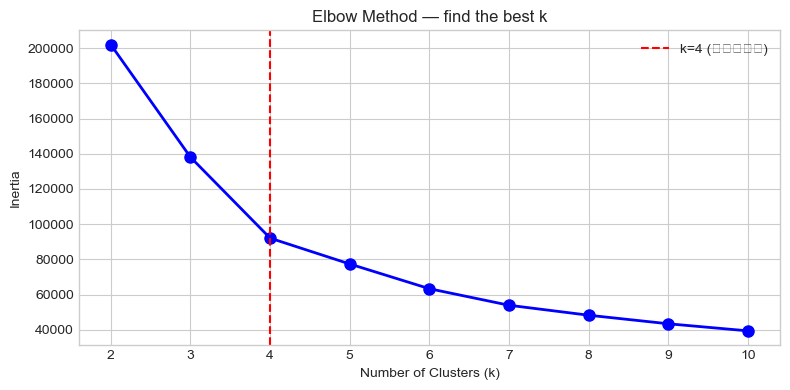

In [7]:
# ทดลอง k ตั้งแต่ 2 ถึง 10 กลุ่ม
# แล้วดูว่า k เท่าไหร่ที่ inertia เริ่มลดน้อยลงแบบ "งอศอก"
inertias = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertias.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method — find the best k')
plt.xticks(k_range)

# ลากเส้นที่ k=4 (คาดว่าจะเป็นจุด elbow)
plt.axvline(x=4, color='red', linestyle='--', label='k=4 (แนะนำ)')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/figures/03_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# รัน K-Means ด้วย k=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['cluster'] = kmeans.fit_predict(rfm_scaled)

# ดูค่าเฉลี่ยของแต่ละกลุ่ม เพื่อตั้งชื่อให้สื่อความหมาย
cluster_summary = rfm.groupby('cluster').agg(
    recency   = ('recency', 'mean'),
    frequency = ('frequency', 'mean'),
    monetary  = ('monetary', 'mean'),
    count     = ('customer_unique_id', 'count')
).round(2)

print(cluster_summary)

         recency  frequency  monetary  count
cluster                                     
0         128.07       1.00    113.37  50746
1         387.34       1.00    114.05  37649
2         237.68       1.01   1142.00   2189
3         220.42       2.11    243.16   2774


In [13]:
# ตั้งชื่อกลุ่มตามลักษณะที่เห็น
# (ดูจากผล cluster_summary ก่อนแล้วค่อยตั้งชื่อให้ตรง)
segment_map = {
    0: 'Champions',       # R น้อย, F มาก, M มาก
    1: 'At Risk',         # R มาก, F ปานกลาง, M ปานกลาง
    2: 'Lost Customers',  # R มากที่สุด, F น้อย, M น้อย
    3: 'Promising',       # R น้อย, F น้อย, M ปานกลาง
}

rfm['segment'] = rfm['cluster'].map(segment_map)
print(rfm['segment'].value_counts())

segment
Champions         50746
At Risk           37649
Promising          2774
Lost Customers     2189
Name: count, dtype: int64


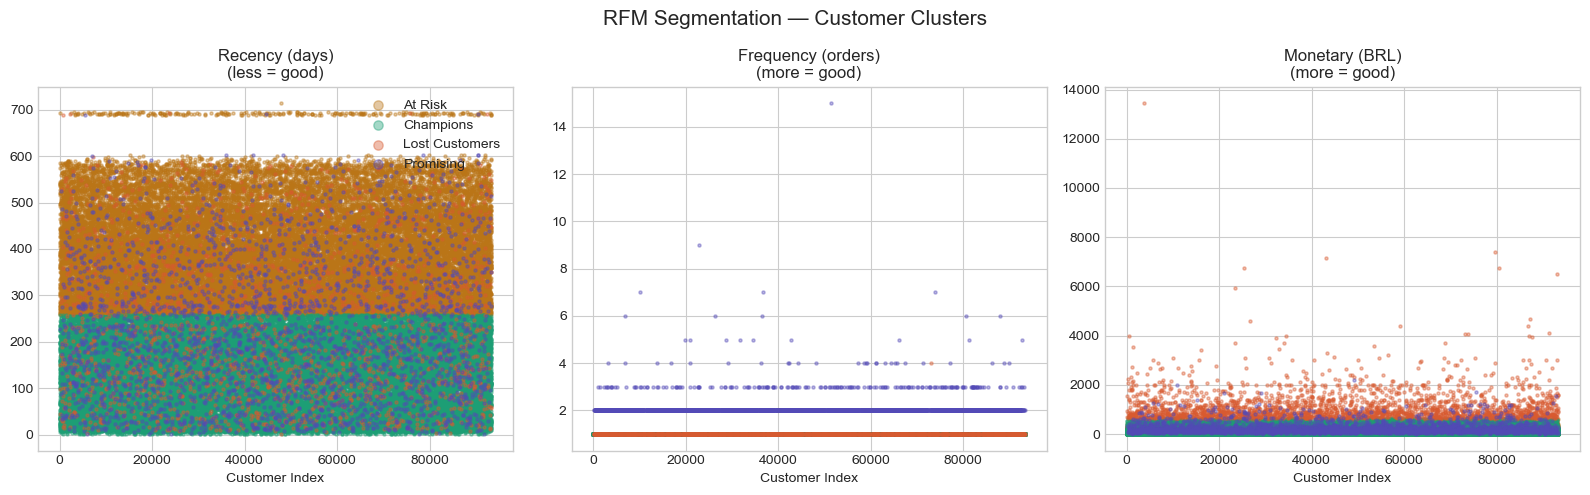

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('RFM Segmentation — Customer Clusters', fontsize=15)

colors = {'Champions': '#1D9E75', 'Promising': '#534AB7',
          'At Risk': '#BA7517', 'Lost Customers': '#D85A30'}

# Plot R, F, M แยกตามกลุ่ม
metrics = [('recency', 'Recency (days)', 'less = good'),
           ('frequency', 'Frequency (orders)', 'more = good'),
           ('monetary', 'Monetary (BRL)', 'more = good')]

for ax, (col, label, note) in zip(axes, metrics):
    for seg, grp in rfm.groupby('segment'):
        ax.scatter(grp.index, grp[col],
                   label=seg, alpha=0.4, s=5,
                   color=colors.get(seg, 'gray'))
    ax.set_title(f'{label}\n({note})')
    ax.set_xlabel('Customer Index')

axes[0].legend(loc='upper right', markerscale=3)
plt.tight_layout()
plt.savefig('../reports/figures/03_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

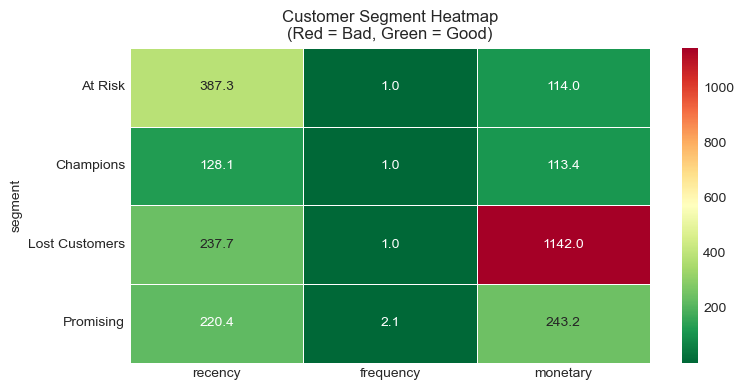

In [17]:
# Heatmap สรุปค่าเฉลี่ยแต่ละกลุ่ม
pivot = rfm.groupby('segment')[['recency','frequency','monetary']].mean().round(1)

plt.figure(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5)
plt.title('Customer Segment Heatmap\n(Red = Bad, Green = Good)')
plt.tight_layout()
plt.savefig('../reports/figures/03_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 💡 Business Recommendations ต่อแต่ละกลุ่ม

| Segment | ลักษณะ | กลยุทธ์ที่แนะนำ |
|---------|--------|----------------|
| Champions | ซื้อล่าสุด, บ่อย, ใช้เงินมาก | Reward program, ให้ early access สินค้าใหม่ |
| Promising | ซื้อล่าสุดแต่ยังไม่บ่อย | ส่ง personalized email, ทำ cross-sell |
| At Risk | เคยดีแต่เริ่มห่างหาย | ส่ง win-back campaign, ให้ส่วนลดพิเศษ |
| Lost Customers | ไม่ซื้อนานมากแล้ว | ส่ง re-engagement email ครั้งสุดท้าย |

In [18]:
# Export ผล segmentation
rfm.to_csv('../data/processed/rfm_segments.csv', index=False)
print("✓ Export เสร็จแล้ว")

✓ Export เสร็จแล้ว
